# C-SON Grid Layout — rapid iteration

Lightweight viewer for the ROMS grid footprints defined in `grids.yml`.
It builds **geometry only** (skips the slow topography and vertical-coordinate
steps in `roms_tools`), so all grids rebuild in ~10 s instead of ~90 s.

**Workflow:** edit `grids.yml`, then re-run the **"Build + plot"** cell at the
bottom. Boundaries are coloured by validation state and labelled by name.


In [1]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import roms_tools as rt

# --- Speed: skip topography + vertical coordinate (we only need lon/lat) ---
# roms_tools computes ETOPO5 topography and the sigma coordinate inside the
# Grid constructor; both are irrelevant for plotting footprints and dominate
# the build time. No-op them so only the horizontal grid (and mask, which the
# coarsening step depends on) is built.
rt.Grid.update_topography = lambda self, *a, **k: None
rt.Grid.update_vertical_coordinate = lambda self, *a, **k: None


def build_grid_geometry(yaml_path="grids.yml"):
    """Return {name: rt.Grid} with horizontal geometry only (fast)."""
    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)["grids"]
    grids, states = {}, {}
    for name, info in cfg.items():
        kw = dict(info["grid_kwargs"])
        kw.pop("topography_source", None)
        grids[name] = rt.Grid(**kw)
        states[name] = info.get("state")
    return grids, states


STATE_COLORS = {
    "Scientifically Validated": "tab:blue",
    "Functionally Validated":   "tab:orange",
    None:                       "tab:purple",
}
STATE_LABELS = {
    "Scientifically Validated": "Scientifically validated",
    "Functionally Validated":   "Functionally validated",
    None:                       "Candidate / unconfigured",
}


def _normalize_lon(lon_raw, seam):
    """Shift longitudes into [seam, seam+360) so each grid is continuous."""
    return (lon_raw - seam) % 360 + seam


def grid_edges(g, seam):
    """Seam-normalised perimeter (lon, lat) walking the grid boundary."""
    lon_raw = g.ds.lon_rho.values
    lat = g.ds.lat_rho.values
    edge_lon = np.concatenate([
        lon_raw[0, :], lon_raw[1:, -1],
        lon_raw[-1, -2::-1], lon_raw[-2:0:-1, 0], lon_raw[0:1, 0],
    ])
    edge_lat = np.concatenate([
        lat[0, :], lat[1:, -1],
        lat[-1, -2::-1], lat[-2:0:-1, 0], lat[0:1, 0],
    ])
    return _normalize_lon(edge_lon, seam), edge_lat


def plot_perimeter(ax, edge_lon, edge_lat, **kwargs):
    """Plot a seam-normalised perimeter, splitting where it jumps the seam."""
    breaks = np.where(np.abs(np.diff(edge_lon)) > 180)[0]
    starts = np.concatenate([[0], breaks + 1])
    ends = np.concatenate([breaks + 1, [len(edge_lon)]])
    for s, e in zip(starts, ends):
        if e - s > 1:
            ax.plot(edge_lon[s:e], edge_lat[s:e],
                    transform=ccrs.PlateCarree(), **kwargs)


Built 19 grid footprints.


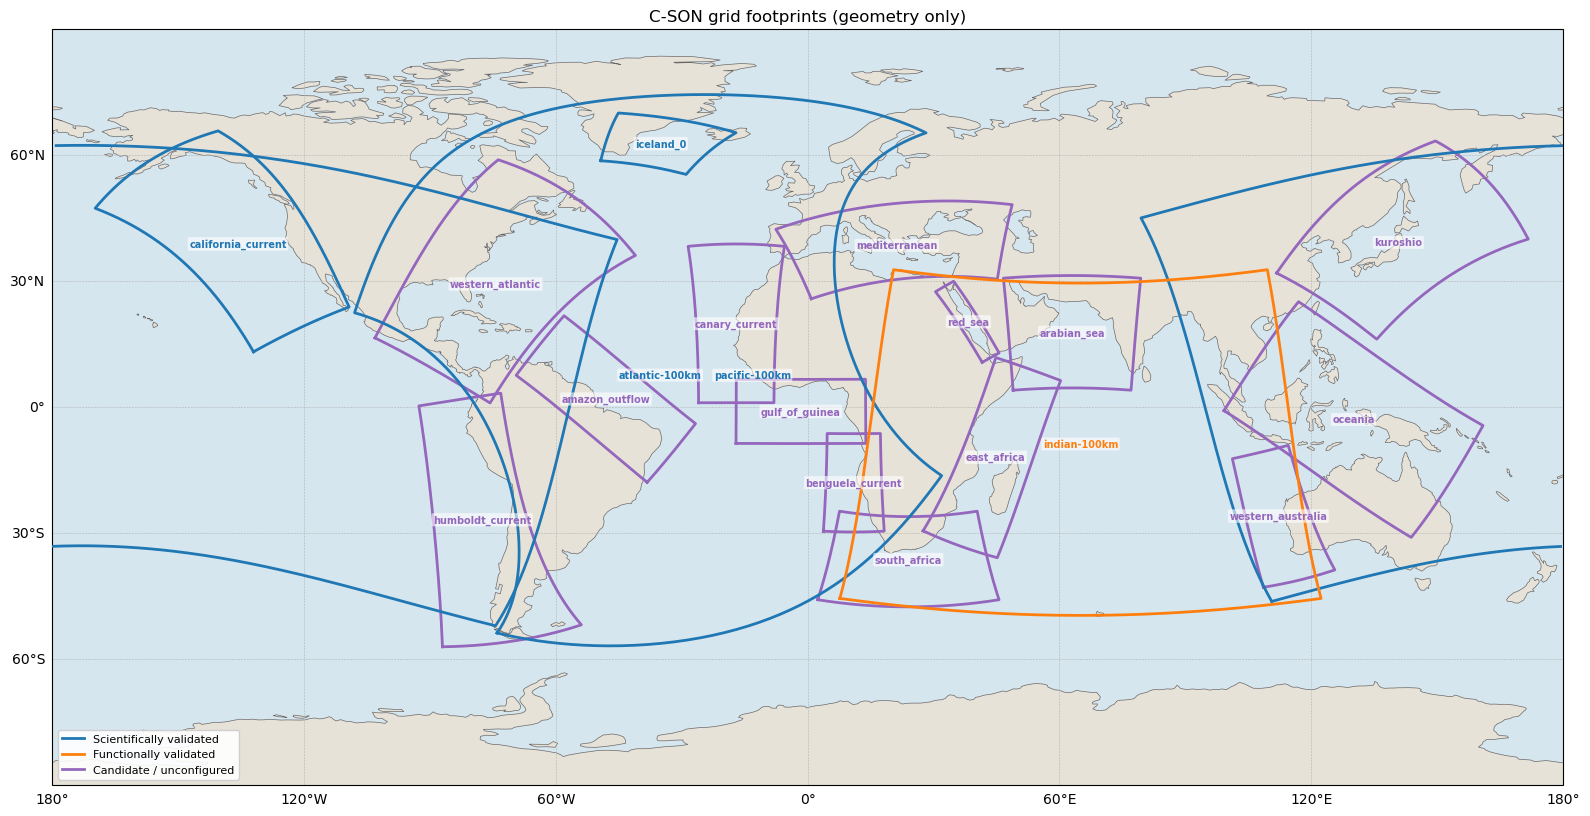

In [2]:
# === Build + plot ===  (re-run this cell after editing grids.yml)
CENTRAL_LON = 0.0          # Greenwich-centred; Atlantic/Africa in the middle
SEAM = CENTRAL_LON - 180   # map seam longitude
EDGE_LINEWIDTH = 2.0

grids, states = build_grid_geometry("grids.yml")
print(f"Built {len(grids)} grid footprints.")

prj = ccrs.PlateCarree(central_longitude=CENTRAL_LON)
fig, ax = plt.subplots(figsize=(16, 9), subplot_kw=dict(projection=prj))

ax.add_feature(cartopy.feature.LAND, facecolor="#e7e2d8", zorder=0)
ax.add_feature(cartopy.feature.OCEAN, facecolor="#d6e6ef", zorder=-1)
ax.coastlines(linewidth=0.5, color="0.4")

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="0.7",
                  linestyle="--")
gl.top_labels = False
gl.right_labels = False

for name, g in grids.items():
    edge_lon, edge_lat = grid_edges(g, SEAM)
    color = STATE_COLORS[states[name]]
    plot_perimeter(ax, edge_lon, edge_lat, color=color,
                   linewidth=EDGE_LINEWIDTH, zorder=5)
    # Label at the footprint centroid
    clon = _normalize_lon(g.ds.lon_rho.values, SEAM).mean()
    clat = float(g.ds.lat_rho.values.mean())
    ax.text(clon, clat, name, transform=ccrs.PlateCarree(),
            ha="center", va="center", fontsize=7, color=color,
            fontweight="bold", zorder=6,
            path_effects=None,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none",
                      alpha=0.6))

# Legend for validation states
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=c, lw=EDGE_LINEWIDTH,
                  label=STATE_LABELS[s])
           for s, c in STATE_COLORS.items()]
ax.legend(handles=handles, loc="lower left", fontsize=8, framealpha=0.9)

ax.set_global()
ax.set_title("C-SON grid footprints (geometry only)")
fig.tight_layout()
fig.savefig("cson-map-grids.png", dpi=150, bbox_inches="tight")
plt.show()
